# Modeled velocity profile from 5S to 16S 

In [17]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.floating_axes as FA
import mpl_toolkits.axisartist.grid_finder as GF

In [18]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [19]:
def anomaly(da, dim='time'):
    """Climatology removal → running mean → drop NaNs"""
    clim = da.groupby(f'{dim}.month').mean(dim=dim)
    anom = da.groupby(f'{dim}.month') - clim
    
    return anom

In [20]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [21]:
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
mask = coastal_band_mask(wmld, 'WMLD', 30)
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(-16,-5))
wmld

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

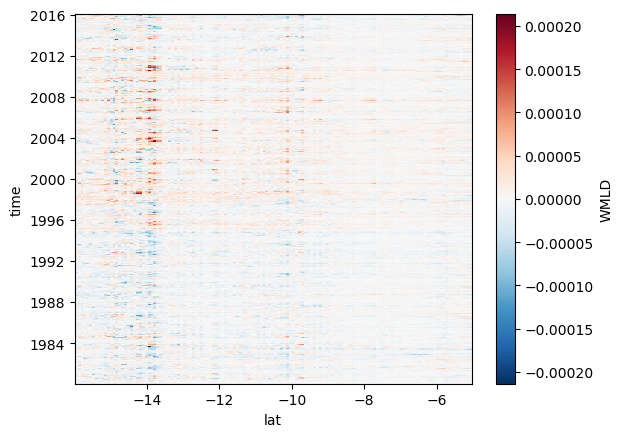

In [22]:
anomaly(wmld).WMLD.mean('lon').plot()

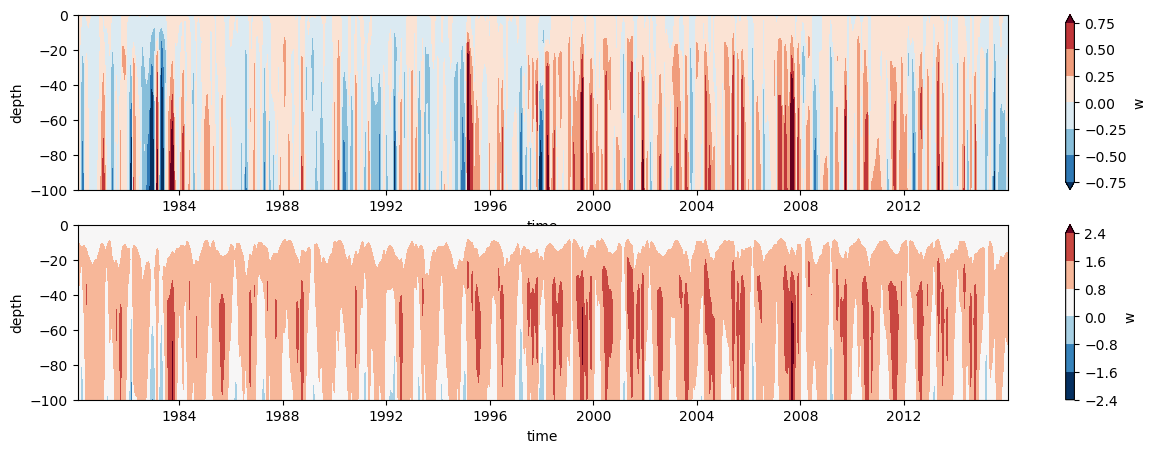

In [23]:
W = xr.open_dataset('W_depth.nc').compute()

fig,ax = plt.subplots(2,1,figsize=(15,5))
anomaly(W.w*86400).sel(depth=slice(0,-100)).plot.contourf(y='depth',robust=True,ax=ax[0])
(W.w*86400).sel(depth=slice(0,-100)).plot.contourf(y='depth',robust=True,ax=ax[1])

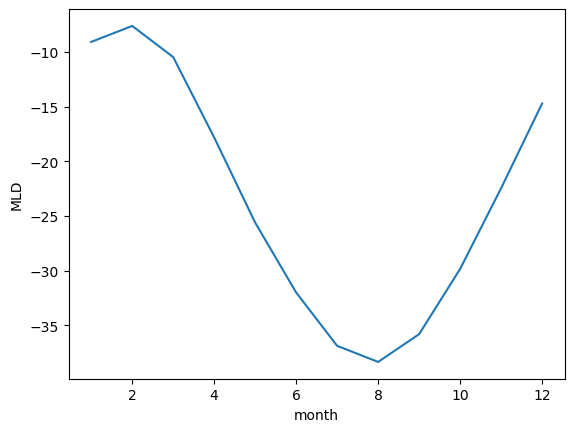

In [24]:
MLD = xr.open_dataset('MLD.nc').compute()
MLD = MLD.where(mask).sel(lon=slice(-85,None),lat=slice(-16,-5))
seasonality(MLD*-1).mean(dim=('lat','lon')).MLD.plot()

Text(0.5, 1.0, 'Seasonality of W at 5S-16S')

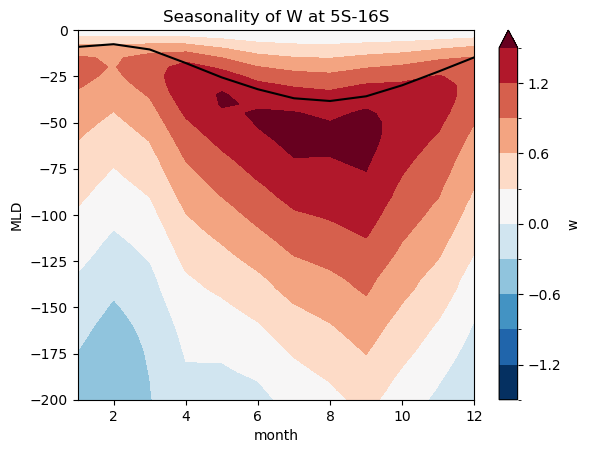

In [25]:

# anomaly(W.w*86400).sel(depth=slice(0,-100)).plot.contourf(y='depth',robust=True,ax=ax[0])
seasonality(W.w*86400).sel(depth=slice(0,-200)).plot.contourf(
    y='depth',robust=True,vmin=-1.5,vmax=1.5, levels=11,cmap='RdBu_r')

seasonality(MLD*-1).mean(dim=('lat','lon')).MLD.plot(color='black')
plt.title('Seasonality of W at 5S-16S')

In [26]:
import datetime

NINO = [
    (datetime.datetime(1982, 8, 1), datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1), datetime.datetime(1998, 8, 30)),
]

def drop_en_events(da, en_windows=NINO, dim='time'):
    """Mask out El Niño periods from a time series."""
    mask = np.ones(da.sizes[dim], dtype=bool)
    time = da[dim].values
    for start, end in en_windows:
        start64 = np.datetime64(start)
        end64   = np.datetime64(end)
        mask &= ~((time >= start64) & (time <= end64))
    return da.isel({dim: mask})

In [27]:
W_all = drop_en_events(W.w*86400).sel(depth=slice(0,-300))
MLD_all = drop_en_events(MLD*-1)
MLD_all.mean()

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    MLD      float64 8B -23.03

In [28]:
W_EN_8384 = (W.w*86400).sel(depth=slice(0,-300)).sel(time=slice("1982-08","1983-12"))
W_EN_9798 = (W.w*86400).sel(depth=slice(0,-300)).sel(time=slice("1997-04","1998-06"))


MLD_EN_8384 = (MLD*-1).sel(time=slice("1982-08","1983-12"))
MLD_EN_9798 = (MLD*-1).sel(time=slice("1997-04","1998-06"))

In [29]:
print(MLD_EN_8384.MLD.mean())
print(MLD_EN_9798.MLD.mean())

<xarray.DataArray 'MLD' ()> Size: 8B
array(-28.58179283)
<xarray.DataArray 'MLD' ()> Size: 8B
array(-26.58466977)


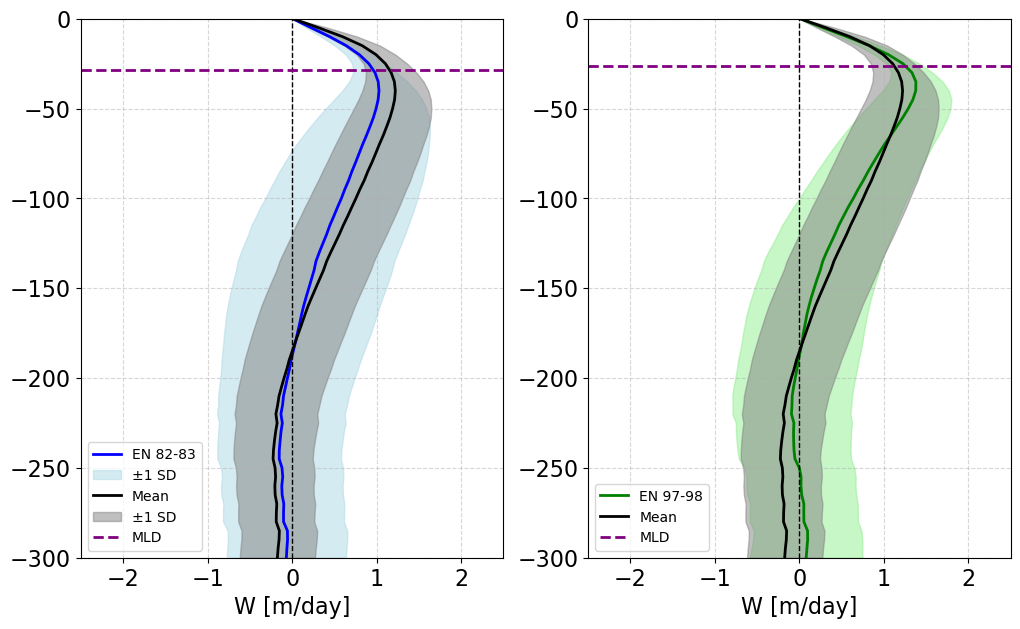

In [30]:
# W_EN_8384.mean('time').w.plot(y='depth')
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,7))

w_mean_EN_8384 = W_EN_8384.mean(dim='time')  # Mean across time for each depth
w_std_EN_8384 = W_EN_8384.std(dim='time')    # Standard deviation across time for each depth

w_mean_EN_9798 = W_EN_9798.mean(dim='time')  # Mean across time for each depth
w_std_EN_9798 = W_EN_9798.std(dim='time')    # Standard deviation across time for each depth

w_mean = W_all.mean(dim='time')
w_std = W_all.std(dim='time')

axes[0].plot(w_mean_EN_8384, W_EN_8384['depth'], color='blue', label='EN 82-83', linewidth=2)
axes[0].fill_betweenx(W_EN_8384['depth'], w_mean_EN_8384 - w_std_EN_8384, w_mean_EN_8384 + w_std_EN_8384, 
                  color='lightblue', alpha=0.5, label='±1 SD')
axes[0].plot(w_mean, W_EN_8384['depth'], color='black', label='Mean', linewidth=2)
axes[0].fill_betweenx(W_EN_8384['depth'], w_mean - w_std, w_mean + w_std, 
                  color='gray', alpha=0.5, label='±1 SD')


# axes[0].set_title('W profile')
axes[0].grid(linestyle='--', alpha=0.5)
axes[0].set_xlabel('W [m/day]',fontsize=16)
# axes[0].set_ylabel('m')
axes[0].set_xlim([-2.5, 2.5])
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].axhline(MLD_EN_8384.MLD.mean(), color='purple', linestyle='--', linewidth=2, label='MLD')

axes[1].plot(w_mean_EN_9798, W_EN_9798['depth'], color='green', label='EN 97-98', linewidth=2)
axes[1].fill_betweenx(W_EN_9798['depth'], w_mean_EN_9798 - w_std_EN_9798, w_mean_EN_9798 + w_std_EN_9798, 
                  color='lightgreen', alpha=0.5)

axes[1].plot(w_mean, W_EN_8384['depth'], color='black', label='Mean', linewidth=2)
axes[1].fill_betweenx(W_EN_8384['depth'], w_mean - w_std, w_mean + w_std, 
                  color='gray', alpha=0.5)

# axes[1].set_title('W profile')
axes[1].grid(linestyle='--', alpha=0.5)
axes[1].set_xlabel('W [m/day]',fontsize=16)
# axes[1].set_ylabel('m')
axes[1].set_xlim([-2.5, 2.5])

axes[1].set_ylim([-300, 0])
axes[0].set_ylim([-300, 0])
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].axhline(MLD_EN_9798.MLD.mean(), color='purple', linestyle='--', linewidth=2, label='MLD')


axes[1].tick_params(axis='both', which='major', labelsize=16)
axes[0].tick_params(axis='both', which='major', labelsize=16)

axes[0].legend()
axes[1].legend()

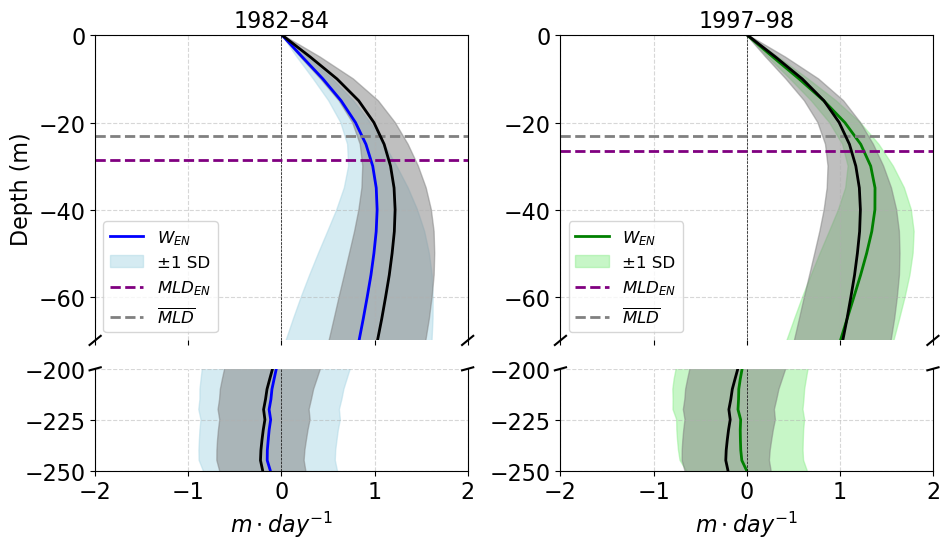

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# --- Compute stats ---
w_mean_EN_8384 = W_EN_8384.mean(dim='time')
w_std_EN_8384  = W_EN_8384.std(dim='time')

w_mean_EN_9798 = W_EN_9798.mean(dim='time')
w_std_EN_9798  = W_EN_9798.std(dim='time')

w_mean = W_all.mean(dim='time')
w_std = W_all.std(dim='time')


depth_8384 = W_EN_8384['depth']
depth_9798 = W_EN_9798['depth']

# --- Figure with broken axes ---
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12*0.8,7*0.8),
    sharex='col',
    gridspec_kw={'height_ratios': [3, 1]}
)

# =========================
# LEFT PANEL (1982–84)
# =========================
for ax in [axes[0,0], axes[1,0]]:
    ax.plot(w_mean_EN_8384, depth_8384, color='blue', lw=2)
    ax.fill_betweenx(
        depth_8384,
        w_mean_EN_8384 - w_std_EN_8384,
        w_mean_EN_8384 + w_std_EN_8384,
        color='lightblue', alpha=0.5
    )
    ax.axvline(0, color='black', linestyle='--', lw=0.5,label='_nolegend_')
    ax.axhline(MLD_EN_8384.MLD.mean(), color='purple', linestyle='--', lw=2)
    ax.axhline(MLD_all.MLD.mean(), color='gray', linestyle='--', lw=2)
    
    ax.plot(w_mean, W_EN_8384['depth'], color='black', label='Mean', linewidth=2)
    ax.fill_betweenx(W_EN_8384['depth'], w_mean - w_std, w_mean + w_std, 
                      color='gray', alpha=0.5, label='±1 SD')

# =========================
# RIGHT PANEL (1997–98)
# =========================
for ax in [axes[0,1], axes[1,1]]:
    ax.plot(w_mean_EN_9798, depth_9798, color='green', lw=2)
    ax.fill_betweenx(
        depth_9798,
        w_mean_EN_9798 - w_std_EN_9798,
        w_mean_EN_9798 + w_std_EN_9798,
        color='lightgreen', alpha=0.5
    )
    ax.axvline(0, color='black', linestyle='--', lw=0.5,label='_nolegend_')
    ax.axhline(MLD_EN_9798.MLD.mean(), color='purple', linestyle='--', lw=2)
    ax.axhline(MLD_all.MLD.mean(), color='gray', linestyle='--', lw=2)

    ax.plot(w_mean, W_EN_8384['depth'], color='black', label='Mean', linewidth=2)
    ax.fill_betweenx(W_EN_8384['depth'], w_mean - w_std, w_mean + w_std, 
                      color='gray', alpha=0.5, label='±1 SD')


# =========================
# Y-limits (the break!)
# =========================
axes[0,0].set_ylim([-70, 0])
axes[0,1].set_ylim([-70, 0])

axes[1,0].set_ylim([-250, -200])
axes[1,1].set_ylim([-250, -200])

# =========================
# Styling
# =========================
for ax in axes.flatten():
    ax.set_xlim([-2, 2])
    ax.grid(linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=14)

# Remove middle spines
for col in range(2):
    axes[0,col].spines['bottom'].set_visible(False)
    axes[1,col].spines['top'].set_visible(False)

    axes[0,col].tick_params(labelbottom=False)

# =========================
# Add break marks
# =========================
d = 0.015

for col in range(2):
    ax_top = axes[0,col]
    ax_bot = axes[1,col]

    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1-d, 1+d), (-d, +d), **kwargs)

    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (1-d, 1+d), **kwargs)
    ax_bot.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# =========================
# Labels & titles
# =========================
axes[1,0].set_xlabel('$m \cdot day^{-1}$', fontsize=16)
axes[1,1].set_xlabel('$m \cdot day^{-1}$', fontsize=16)

axes[0,0].set_title('1982–84', fontsize=16)
axes[0,1].set_title('1997–98', fontsize=16)

axes[0,0].set_ylabel('Depth (m)', fontsize=16)
# axes[1,0].set_ylabel('Depth (m)', fontsize=16)

# =========================
# Legend (only once)
# =========================
axes[0,0].legend(['$W_{EN}$', '±1 SD','$MLD_{EN}$',r'$\overline{MLD}$'], fontsize=12)
axes[0,1].legend(['$W_{EN}$', '±1 SD','$MLD_{EN}$',r'$\overline{MLD}$'], fontsize=12)

axes[1,0].tick_params(axis='both', which='major', labelsize=16)
axes[1,1].tick_params(axis='both', which='major', labelsize=16)
axes[0,0].tick_params(axis='both', which='major', labelsize=16)
axes[0,1].tick_params(axis='both', which='major', labelsize=16)


plt.tight_layout()
# # --- Save ---
# with PdfPages('figures/Upwelling_w_absolute.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

In [32]:
W_EN_8384 = anomaly(W.w*86400).sel(depth=slice(0,-300)).sel(time=slice("1982-08","1983-12"))
W_EN_9798 = anomaly(W.w*86400).sel(depth=slice(0,-300)).sel(time=slice("1997-04","1998-06"))


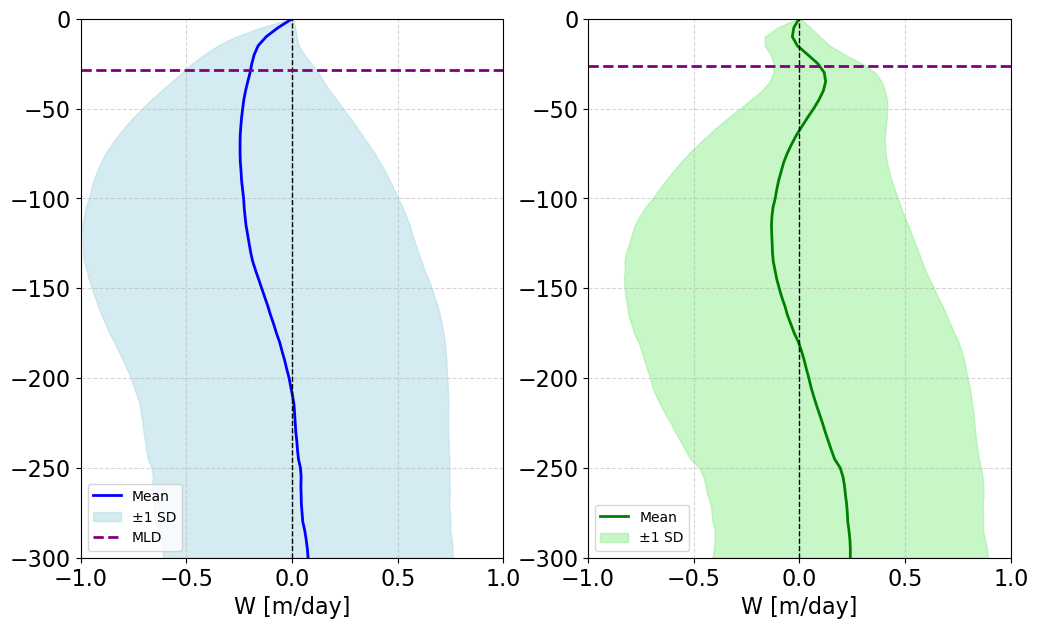

In [33]:
# W_EN_8384.mean('time').w.plot(y='depth')
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,7))

w_mean_EN_8384 = W_EN_8384.mean(dim='time')  # Mean across time for each depth
w_std_EN_8384 = W_EN_8384.std(dim='time')    # Standard deviation across time for each depth

w_mean_EN_9798 = W_EN_9798.mean(dim='time')  # Mean across time for each depth
w_std_EN_9798 = W_EN_9798.std(dim='time')    # Standard deviation across time for each depth

axes[0].plot(w_mean_EN_8384, W_EN_8384['depth'], color='blue', label='Mean', linewidth=2)
axes[0].fill_betweenx(W_EN_8384['depth'], w_mean_EN_8384 - w_std_EN_8384, w_mean_EN_8384 + w_std_EN_8384, 
                  color='lightblue', alpha=0.5, label='±1 SD')
# axes[0].set_title('W profile')
axes[0].grid(linestyle='--', alpha=0.5)
axes[0].set_xlabel('W [m/day]',fontsize=16)
# axes[0].set_ylabel('m')
axes[0].set_xlim([-1, 1])
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].axhline(MLD_EN_8384.MLD.mean(), color='purple', linestyle='--', linewidth=2,label='MLD')

axes[1].plot(w_mean_EN_9798, W_EN_9798['depth'], color='green', label='Mean', linewidth=2)
axes[1].fill_betweenx(W_EN_9798['depth'], w_mean_EN_9798 - w_std_EN_9798, w_mean_EN_9798 + w_std_EN_9798, 
                  color='lightgreen', alpha=0.5, label='±1 SD')
# axes[1].set_title('W profile')
axes[1].grid(linestyle='--', alpha=0.5)
axes[1].set_xlabel('W [m/day]',fontsize=16)

# axes[1].set_ylabel('m')
axes[1].set_xlim([-1, 1])
axes[1].set_ylim([-300, 0])
axes[0].set_ylim([-300, 0])
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].axhline(MLD_EN_9798.MLD.mean(), color='purple', linestyle='--', linewidth=2,label='')


axes[1].tick_params(axis='both', which='major', labelsize=16)
axes[0].tick_params(axis='both', which='major', labelsize=16)

axes[0].legend()
axes[1].legend()

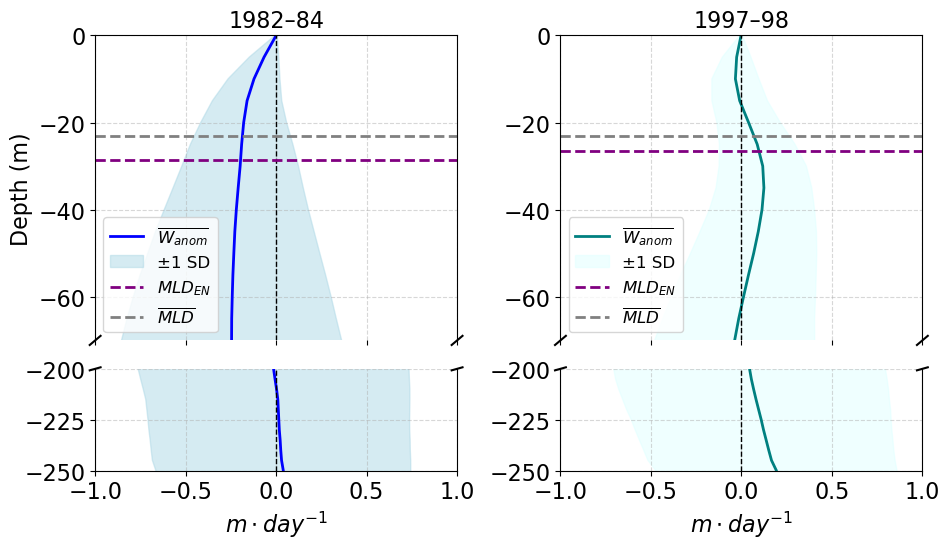

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# --- Compute stats ---
w_mean_EN_8384 = W_EN_8384.mean(dim='time')
w_std_EN_8384  = W_EN_8384.std(dim='time')

w_mean_EN_9798 = W_EN_9798.mean(dim='time')
w_std_EN_9798  = W_EN_9798.std(dim='time')

depth_8384 = W_EN_8384['depth']
depth_9798 = W_EN_9798['depth']

# --- Figure with broken axes ---
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12*0.8,7*0.8),
    sharex='col',
    gridspec_kw={'height_ratios': [3, 1]}
)

# =========================
# LEFT PANEL (1982–84)
# =========================
for ax in [axes[0,0], axes[1,0]]:
    ax.plot(w_mean_EN_8384, depth_8384, color='blue', lw=2)
    ax.fill_betweenx(
        depth_8384,
        w_mean_EN_8384 - w_std_EN_8384,
        w_mean_EN_8384 + w_std_EN_8384,
        color='lightblue', alpha=0.5
    )
    ax.axvline(0, color='black', linestyle='--', lw=1,label='_nolegend_')
    ax.axhline(MLD_EN_8384.MLD.mean(), color='purple', linestyle='--', lw=2)
    ax.axhline(MLD_all.MLD.mean(), color='gray', linestyle='--', lw=2)

# =========================
# RIGHT PANEL (1997–98)
# =========================
for ax in [axes[0,1], axes[1,1]]:
    ax.plot(w_mean_EN_9798, depth_9798, color='teal', lw=2)
    ax.fill_betweenx(
        depth_9798,
        w_mean_EN_9798 - w_std_EN_9798,
        w_mean_EN_9798 + w_std_EN_9798,
        color='lightcyan', alpha=0.5
    )
    ax.axvline(0, color='black', linestyle='--', lw=1,label='_nolegend_')
    ax.axhline(MLD_EN_9798.MLD.mean(), color='purple', linestyle='--', lw=2)
    ax.axhline(MLD_all.MLD.mean(), color='gray', linestyle='--', lw=2)

# =========================
# Y-limits (the break!)
# =========================
axes[0,0].set_ylim([-70, 0])
axes[0,1].set_ylim([-70, 0])

axes[1,0].set_ylim([-250, -200])
axes[1,1].set_ylim([-250, -200])

# =========================
# Styling
# =========================
for ax in axes.flatten():
    ax.set_xlim([-1, 1])
    ax.grid(linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=14)

# Remove middle spines
for col in range(2):
    axes[0,col].spines['bottom'].set_visible(False)
    axes[1,col].spines['top'].set_visible(False)

    axes[0,col].tick_params(labelbottom=False)

# =========================
# Add break marks
# =========================
d = 0.015

for col in range(2):
    ax_top = axes[0,col]
    ax_bot = axes[1,col]

    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1-d, 1+d), (-d, +d), **kwargs)

    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (1-d, 1+d), **kwargs)
    ax_bot.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# =========================
# Labels & titles
# =========================
axes[1,0].set_xlabel('$m \cdot day^{-1}$', fontsize=16)
axes[1,1].set_xlabel('$m \cdot day^{-1}$', fontsize=16)

axes[0,0].set_title('1982–84', fontsize=16)
axes[0,1].set_title('1997–98', fontsize=16)

axes[0,0].set_ylabel('Depth (m)', fontsize=16)
# axes[1,0].set_ylabel('Depth (m)', fontsize=16)

# =========================
# Legend (only once)
# =========================
axes[0,0].legend(['$\overline{W_{anom}}$', '±1 SD','$MLD_{EN}$',r'$\overline{MLD}$'], fontsize=12)
axes[0,1].legend(['$\overline{W_{anom}}$', '±1 SD','$MLD_{EN}$',r'$\overline{MLD}$'], fontsize=12)

axes[1,0].tick_params(axis='both', which='major', labelsize=16)
axes[1,1].tick_params(axis='both', which='major', labelsize=16)
axes[0,0].tick_params(axis='both', which='major', labelsize=16)
axes[0,1].tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()

# --- Save ---
# with PdfPages('figures/Upwelling_w_anom.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')


plt.show()

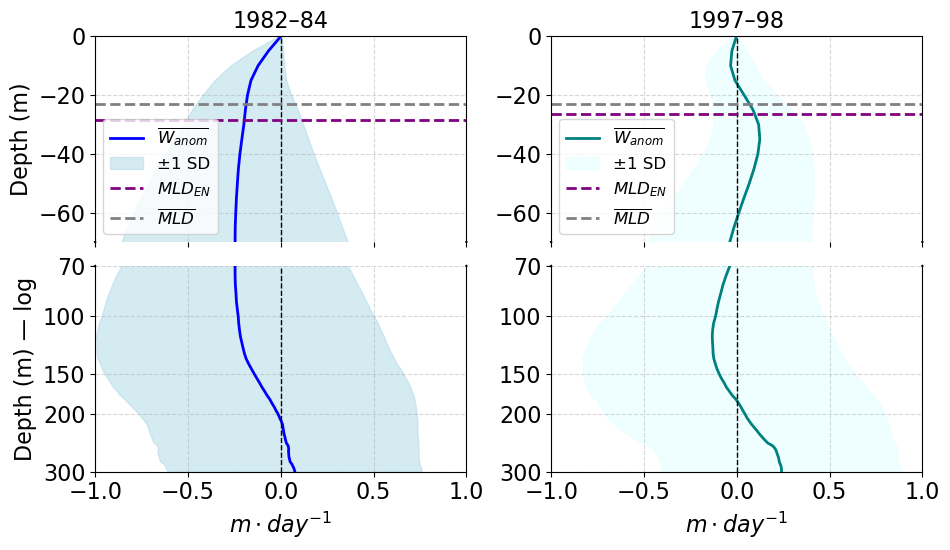

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# --- Compute stats ---
w_mean_EN_8384 = W_EN_8384.mean(dim='time')
w_std_EN_8384  = W_EN_8384.std(dim='time')
w_mean_EN_9798 = W_EN_9798.mean(dim='time')
w_std_EN_9798  = W_EN_9798.std(dim='time')
depth_8384 = W_EN_8384['depth']
depth_9798 = W_EN_9798['depth']

# --- Figure: 2 rows, 2 cols ---
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12*0.8, 7*0.8),
    sharex='col',
    gridspec_kw={'height_ratios': [1, 1]}
)

# Helper to plot one profile
def plot_profile(ax, w_mean, w_std, depth, color, fill_color, mld_en, mld_all):
    ax.plot(w_mean, depth, color=color, lw=2)
    ax.fill_betweenx(
        depth,
        w_mean - w_std,
        w_mean + w_std,
        color=fill_color, alpha=0.5
    )
    ax.axvline(0, color='black', linestyle='--', lw=1, label='_nolegend_')
    ax.axhline(mld_en, color='purple', linestyle='--', lw=2)
    ax.axhline(mld_all, color='gray', linestyle='--', lw=2)

mld_en_82 = float(MLD_EN_8384.MLD.mean())
mld_en_97 = float(MLD_EN_9798.MLD.mean())
mld_all_val = float(MLD_all.MLD.mean())

# =========================
# TOP ROW: Linear scale (0 to -70 m)
# =========================
plot_profile(axes[0,0], w_mean_EN_8384, w_std_EN_8384, depth_8384,
             'blue', 'lightblue', mld_en_82, mld_all_val)
plot_profile(axes[0,1], w_mean_EN_9798, w_std_EN_9798, depth_9798,
             'teal', 'lightcyan', mld_en_97, mld_all_val)

axes[0,0].set_ylim([-70, 0])
axes[0,1].set_ylim([-70, 0])

# =========================
# BOTTOM ROW: Log scale (-70 to deepest)
# =========================
plot_profile(axes[1,0], w_mean_EN_8384, w_std_EN_8384, depth_8384,
             'blue', 'lightblue', mld_en_82, mld_all_val)
plot_profile(axes[1,1], w_mean_EN_9798, w_std_EN_9798, depth_9798,
             'teal', 'lightcyan', mld_en_97, mld_all_val)

# Log scale on depth (negative values, so we work with |depth|)
for col in range(2):
    ax = axes[1, col]
    # Get the depth range below 70 m
    ax.set_ylim([-300, -70])
    ax.set_yscale('symlog', linthresh=70)
    # Manual tick labels for clarity
    ax.set_yticks([-70, -100, -150, -200, -300])
    ax.set_yticklabels(['70', '100', '150', '200', '300'])

# =========================
# Styling
# =========================
for ax in axes.flatten():
    ax.set_xlim([-1, 1])
    ax.grid(linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=16)

# Remove spines between panels
for col in range(2):
    axes[0, col].spines['bottom'].set_visible(False)
    axes[1, col].spines['top'].set_visible(False)
    axes[0, col].tick_params(labelbottom=False)

# Add break marks
d = 0.0001
for col in range(2):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1-d, 1+d), (-d, +d), **kwargs)
    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (1-d, 1+d), **kwargs)
    ax_bot.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# =========================
# Labels & titles
# =========================
axes[1,0].set_xlabel(r'$m \cdot day^{-1}$', fontsize=16)
axes[1,1].set_xlabel(r'$m \cdot day^{-1}$', fontsize=16)
axes[0,0].set_title('1982–84', fontsize=16)
axes[0,1].set_title('1997–98', fontsize=16)
axes[0,0].set_ylabel('Depth (m)', fontsize=16)
axes[1,0].set_ylabel('Depth (m) — log', fontsize=16)

# =========================
# Legend
# =========================
axes[0,0].legend([r'$\overline{W_{anom}}$', '±1 SD', '$MLD_{EN}$', r'$\overline{MLD}$'], fontsize=12)
axes[0,1].legend([r'$\overline{W_{anom}}$', '±1 SD', '$MLD_{EN}$', r'$\overline{MLD}$'], fontsize=12)

plt.tight_layout()

# with PdfPages('figures/Upwelling_w_anom.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

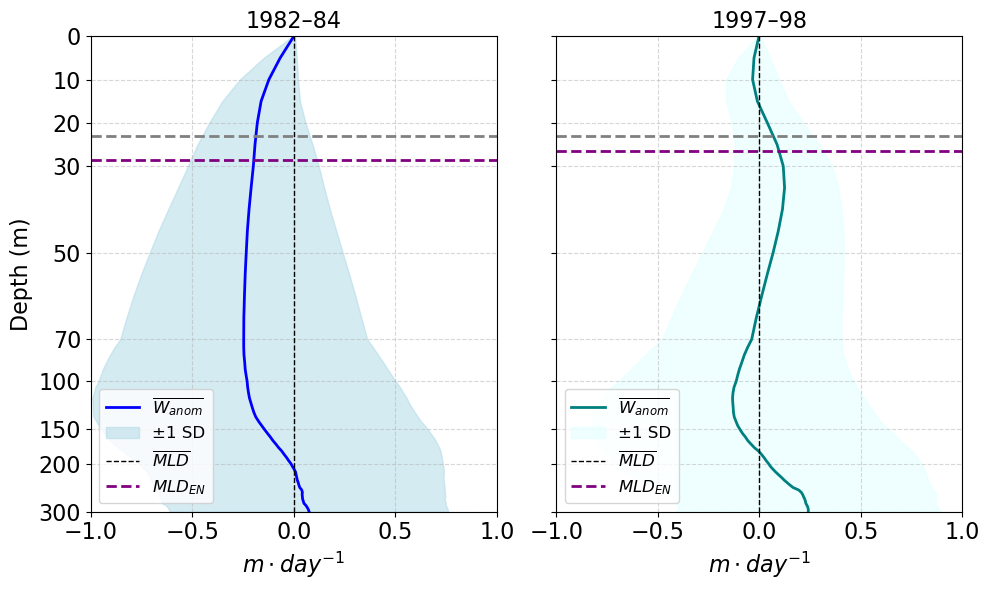

In [36]:
import matplotlib.pyplot as plt
import numpy as np

w_mean_EN_8384 = W_EN_8384.mean(dim='time')
w_std_EN_8384  = W_EN_8384.std(dim='time')
w_mean_EN_9798 = W_EN_9798.mean(dim='time')
w_std_EN_9798  = W_EN_9798.std(dim='time')
depth_8384 = W_EN_8384['depth']
depth_9798 = W_EN_9798['depth']

mld_en_82 = float(MLD_EN_8384.MLD.mean())
mld_en_97 = float(MLD_EN_9798.MLD.mean())
mld_all_val = float(MLD_all.MLD.mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# --- Left: 1982-84 ---
ax1.plot(w_mean_EN_8384, depth_8384, color='blue', lw=2)
ax1.fill_betweenx(depth_8384, w_mean_EN_8384 - w_std_EN_8384,
                   w_mean_EN_8384 + w_std_EN_8384, color='lightblue', alpha=0.5)
ax1.axvline(0, color='black', linestyle='--', lw=1)
ax1.axhline(mld_en_82, color='purple', linestyle='--', lw=2)
ax1.axhline(mld_all_val, color='gray', linestyle='--', lw=2)

# --- Right: 1997-98 ---
ax2.plot(w_mean_EN_9798, depth_9798, color='teal', lw=2)
ax2.fill_betweenx(depth_9798, w_mean_EN_9798 - w_std_EN_9798,
                   w_mean_EN_9798 + w_std_EN_9798, color='lightcyan', alpha=0.5)
ax2.axvline(0, color='black', linestyle='--', lw=1)
ax2.axhline(mld_en_97, color='purple', linestyle='--', lw=2)
ax2.axhline(mld_all_val, color='gray', linestyle='--', lw=2)

# --- Symlog y-axis: linear near surface, log at depth ---
for ax in [ax1, ax2]:
    ax.set_yscale('symlog', linthresh=70)
    ax.set_ylim([-300, 0])
    ax.set_xlim([-1, 1])
    ax.set_yticks([0, -10, -20, -30, -50, -70, -100, -150, -200, -300])
    ax.set_yticklabels(['0', '10', '20', '30', '50', '70', '100', '150', '200', '300'])
    ax.grid(linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_xlabel(r'$m \cdot day^{-1}$', fontsize=16)

ax1.set_ylabel('Depth (m)', fontsize=16)
ax1.set_title('1982–84', fontsize=16)
ax2.set_title('1997–98', fontsize=16)

ax1.legend([r'$\overline{W_{anom}}$', '±1 SD', r'$\overline{MLD}$','$MLD_{EN}$'], fontsize=12)
ax2.legend([r'$\overline{W_{anom}}$', '±1 SD', r'$\overline{MLD}$','$MLD_{EN}$'], fontsize=12)

plt.tight_layout()
plt.show()